In [1]:
import jax
import jax.numpy as jnp
from jax import value_and_grad, jit, vmap
import openmm.app as apps
import openmm.unit as unit
from openmm import app
from openmm.app import ForceField

from dmff import Hamiltonian, NeighborList
from dmff.api.xmlio import XMLIO
from dmff.api.paramset import ParamSet
from dmff.operators.templatetype import TemplateATypeOperator
import dmff
from dmff.generators.classical import PeriodicTorsionGenerator, NonbondedGenerator

import copy, os
import matplotlib.pyplot as plt
import numpy as np
from tqdm.notebook import tqdm

from ase.io import read,write
from ase.visualize import view

from imolcryff.molinfo import load_molinfo

/Users/srak/apl/imolcryff/DMFF/dmff/admp/qeq.py:33: UserWarning: jaxopt not found, QEQ cannot be used.
  warnings.warn("jaxopt not found, QEQ cannot be used.")


In [2]:
ff = Hamiltonian("gaffxml_0.xml")
molinfo = load_molinfo("molinfo.pkl")
mmm = molinfo.get_molecule_omm()
top = mmm[0].to_topology().to_openmm()
potentials = ff.createPotential(top)
efunc = potentials.getPotentialFunc()

io = XMLIO()
io.loadXML("gaffxml_0.xml")
ffinfo = io.parseXML()
topdata = dmff.DMFFTopology(top)
operator = TemplateATypeOperator(ffinfo)
operator.operate(topdata)
for na, a in enumerate(topdata._meta):
    print(a)
paramset_dihed = ParamSet()
torsion_gen = PeriodicTorsionGenerator(ffinfo, paramset_dihed)

[16:34:55] atom 8 has specified valence (1) smaller than the drawn valence 2.


In [3]:
forcefield = ForceField("gaffxml_0.xml", "gaffxml_1.xml", "gaffxml_2.xml")
system = forcefield.createSystem(mmm[0].to_topology().to_openmm(), nonbondedMethod=app.NoCutoff)

[16:34:55] atom 8 has specified valence (1) smaller than the drawn valence 2.


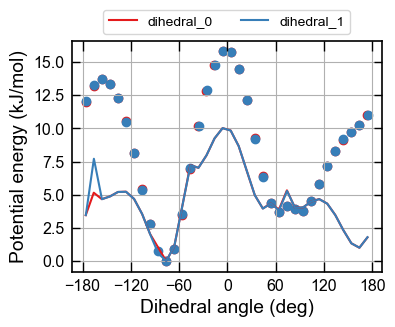

In [4]:
from imolcryff.molinfo import draw_dihedral_plots
molinfo.get_dihedral_ff(forcefield=forcefield)
gt, ff_scan = draw_dihedral_plots(molinfo, "MOL_0")

In [5]:
@jit
def MSELoss(params0: ParamSet, ffparams, positions, box, pairs, gt_Etot):
    kT = 2.494 # 300 K = 2.494 kJ/mol
    assert len(positions) == len(gt_Etot)
    assert len(positions) == len(pairs)
    
    gt_Etot = gt_Etot - gt_Etot.min()
    gt_Etot = jnp.array(gt_Etot)
    weights_pts = jnp.piecewise(gt_Etot, [gt_Etot<25, gt_Etot>=25], [lambda x: jnp.array(1.0), lambda x: jnp.exp(-(x-25)/kT)])
    npts = len(weights_pts)
    
    # setting up params for all calculators
    params_dihed = {} 
    params_dihed["PeriodicTorsionForce"] = {}
    params_dihed["PeriodicTorsionForce"]["proper_phase"] = params0["PeriodicTorsionForce"]["proper_phase"]
    params_dihed["PeriodicTorsionForce"]["proper_k"] = params0["PeriodicTorsionForce"]["proper_k"]

    p = copy.deepcopy(ffparams)
    p['PeriodicTorsionForce']["proper_phase"] = params_dihed["PeriodicTorsionForce"]["proper_phase"]
    p['PeriodicTorsionForce']["proper_k"] = params_dihed["PeriodicTorsionForce"]["proper_k"]

    # calculate each points, only the short range and damping components
    totene_ff = jnp.zeros(npts)
    for ipt in range(npts):
        totene_ff = totene_ff.at[ipt].set(efunc(positions[ipt], box, pairs[ipt], p))
    
    totene_ff = totene_ff - totene_ff.min()
        
    dE = totene_ff - gt_Etot
    mse = dE**2 * weights_pts / jnp.sum(weights_pts)
    mse = jnp.sum(mse)

    return mse

In [6]:
def get_relaxedcoord_dihedconst(top, positions_ary, dihed_atomid, dihed_angle, ffxml):
    from openmm.unit import degree, kilojoules_per_mole, kelvin, picosecond, picoseconds
    from openmm.app import NoCutoff, Simulation
    from openmm import PeriodicTorsionForce, LangevinMiddleIntegrator
    from openmm.app import PDBFile
    positions_list = []
    for i_angle, angle_deg in enumerate(dihed_angle):
        forcefield = ForceField(ffxml)
        system = forcefield.createSystem(top, nonbondedMethod=NoCutoff)
        restraint = PeriodicTorsionForce()
        d1 = dihed_atomid[0]
        d2 = dihed_atomid[1]
        d3 = dihed_atomid[2]
        d4 = dihed_atomid[3]
        restraint.addTorsion(d1,d2,d3,d4, 1, (angle_deg+180)*degree, 1000*kilojoules_per_mole)
        system.addForce(restraint)
        integrator = LangevinMiddleIntegrator(300*kelvin, 1/picosecond, 0.004*picoseconds)
        simulation = Simulation(top, system, integrator)
        simulation.context.setPositions(positions_ary[i_angle])
        simulation.minimizeEnergy()
        state = simulation.context.getState(getPositions=True, getEnergy=True)
        positions_list.append(state.getPositions(asNumpy=True))
    return positions_list

In [7]:
def get_pospairs_dihedral(molinfo_dict, top, dihed_idx, ffxml):
    dihed_angle = molinfo_dict["dihedral_angle"][dihed_idx]
    dihed_atomid = molinfo_dict['rotatable_dihedral'][dihed_idx]
    dihed_ase = molinfo_dict['dihedral_aseatoms'][dihed_idx]
    positions_ary = np.array([np.array(dihed_ase[i].positions / 10) for i in range(len(dihed_ase))])
    positions = get_relaxedcoord_dihedconst(top, positions_ary, dihed_atomid, dihed_angle, ffxml)
    jnp_positions = jnp.array([jnp.array(positions[i]) for i in range(len(positions))])

    box = jnp.array([
            [1000.0,  0.0,  0.0],
            [ 0.0, 1000.0,  0.0],
            [ 0.0,  0.0, 1000.0]
        ])

    jnp_pairs= []
    for i_dihed in range(len(dihed_ase)):
        nbList = NeighborList(box, rcut=40, cov_map=potentials.meta["cov_map"])
        nbList.allocate(jnp_positions[i_dihed])
        jnp_pairs.append(nbList.pairs)

    jnp_pairs = jnp.array(jnp_pairs)

    return jnp_positions, box, jnp_pairs

def get_gt_Etot(molinfo, molname, idx):
    from ase import units
    gt_Etot = molinfo.mol_info[molname]["dihedral_energy"][idx]
    gt_Etot = (gt_Etot - gt_Etot.min()) / (units.kJ * (units.mol**-1))
    gt_Etot = jnp.array(gt_Etot)
    return gt_Etot

In [8]:
ff.getParameters().to_jax()
paramset0 = ff.getParameters()
paramset0

In [9]:
jnp_positions, jnp_box, jnp_pairs = get_pospairs_dihedral(molinfo.mol_info["MOL_0"], top, 0, "gaffxml_0.xml")
dihedral_qm = get_gt_Etot(molinfo, "MOL_0", 0)
a = MSELoss(paramset0, paramset0, jnp_positions, jnp_box, jnp_pairs, dihedral_qm)
print(a)

26.514985617293313


In [10]:
MSELoss_grad = jit(value_and_grad(MSELoss, argnums=(0)))
err, gradients = MSELoss_grad(paramset0, paramset0, jnp_positions, jnp_box, jnp_pairs, dihedral_qm)

In [11]:
def add_grad(grad1:ParamSet, grad2:ParamSet):
    for k in grad1.parameters.keys():
        for t in grad1.parameters[k].keys():
            grad1.parameters[k][t] += grad2.parameters[k][t]
    return ParamSet(grad1.parameters, grad1.mask)

In [12]:
import optax
import sys
# start to do optmization


lr = 0.005
opt = optax.adam(lr)

opt_state = opt.init(paramset_dihed)

jnp_positions_list = []
jnp_box_list = []
jnp_pairs_list = []
dihedral_qm_list = []
for i, i_dihed in enumerate([0,1]):
    jnp_positions, jnp_box, jnp_pairs = get_pospairs_dihedral(molinfo.mol_info["MOL_0"], top, i_dihed, "gaffxml_0.xml")
    dihedral_qm = get_gt_Etot(molinfo, "MOL_0", i_dihed)
    jnp_positions_list.append(jnp_positions)
    jnp_box_list.append(jnp_box)
    jnp_pairs_list.append(jnp_pairs)
    dihedral_qm_list.append(dihedral_qm)


n_epochs = 40000
best_loss = 1e10
for i_epoch in tqdm(range(1,n_epochs+1)):
    for i, i_dihed in enumerate([0,1]):
        loss_tmp, grads_tmp = MSELoss_grad(paramset_dihed, paramset0, jnp_positions_list[i], jnp_box_list[i], jnp_pairs_list[i], dihedral_qm_list[i])
        if i == 0:
            loss = loss_tmp
            grads = grads_tmp
        else:
            loss += loss_tmp
            grads = add_grad(grads, grads_tmp)

    if loss < best_loss:
        best_loss = loss
        best_params = paramset_dihed
    sys.stdout.flush()
    updates, opt_state = opt.update(grads, opt_state)
    paramset_dihed = optax.apply_updates(paramset_dihed, updates)
    # paramset_dihed = jax.tree_map(lambda x: jnp.clip(x, 0.0, 1e8), paramset_dihed)
    torsion_gen.overwrite(paramset_dihed)
    if i_epoch % 100 == 0:
        print(f"epoch: {i_epoch}, loss: {loss}")
    if i_epoch % 10000 == 0:
        io.writeXML(f"loop-{i_epoch}.xml", ffinfo)

  0%|          | 0/40000 [00:00<?, ?it/s]

epoch: 100, loss: 20.53470420885457
epoch: 200, loss: 11.611601749335879
epoch: 300, loss: 10.50745748173232
epoch: 400, loss: 10.433421008221908
epoch: 500, loss: 10.425807465450738
epoch: 600, loss: 10.419672190206624
epoch: 700, loss: 10.412995585388341
epoch: 800, loss: 10.405791126864642
epoch: 900, loss: 10.398096238702134
epoch: 1000, loss: 10.389944026970706
epoch: 1100, loss: 10.381364057036242
epoch: 1200, loss: 10.37238298114491
epoch: 1300, loss: 10.36302493673529
epoch: 1400, loss: 10.35331180154029
epoch: 1500, loss: 10.343263358393136
epoch: 1600, loss: 10.332897402447308
epoch: 1700, loss: 10.322229811644611
epoch: 1800, loss: 10.311274593984347
epoch: 1900, loss: 10.3000439205033
epoch: 2000, loss: 10.288548149820087
epoch: 2100, loss: 10.276795848035338
epoch: 2200, loss: 10.264793806355563
epoch: 2300, loss: 10.252547057815885
epoch: 2400, loss: 10.24005889378042
epoch: 2500, loss: 10.227330880409632
epoch: 2600, loss: 10.21436287495076
epoch: 2700, loss: 10.20115304

In [13]:
import pickle
with open('params.pickle', 'wb') as ofile:
    pickle.dump(best_params, ofile)

In [14]:
import pickle
with open('params.pickle',"rb") as ofile:
    best_params = pickle.load(ofile)

torsion_gen.overwrite(best_params)
io.writeXML("best.xml", ffinfo)

In [15]:
def ff_dihed(jnp_positions_ary, params):
    # dihed_ase = molinfo.mol_info["MOL_0"]["dihedral_aseatoms"][id]
    totenes = []
    for i_dihed in range(len(jnp_positions_ary)):
        jnp_positions = jnp_positions_ary[i_dihed]
        box = jnp.array([
            [1000.0,  0.0,  0.0],
            [ 0.0, 1000.0,  0.0],
            [ 0.0,  0.0, 1000.0]
        ])
        nbList = NeighborList(box, rcut=40, cov_map=potentials.meta["cov_map"])
        nbList.allocate(jnp_positions)
        pairs = nbList.pairs
        efunc = potentials.getPotentialFunc()
        totene = efunc(jnp_positions, box, pairs, params)
        totenes.append(totene)
    totenes = np.array(totenes)
    return totenes

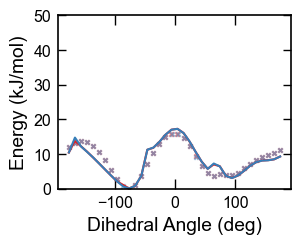

In [16]:
cmap = plt.get_cmap('Set1')
from ase import units
best_params = Hamiltonian("best.xml").getParameters()
# best_params = Hamiltonian("gaffxml_0.xml").getParameters()
plt.ylim(0, 50)
plt.xlabel("Dihedral Angle (deg)")
plt.ylabel("Energy (kJ/mol)")
for id in range(2):
    totenes = ff_dihed(jnp_positions_list[id], best_params)
    totenes = totenes - totenes.min()
    dihed = molinfo.mol_info["MOL_0"]["dihedral_angle"][id]
    plt.plot(dihed,totenes,color=cmap(id))
    plt.scatter(dihed, gt[id],color=cmap(id),marker='x',s=10,alpha=0.5)
    # plt.plot(dihed, ff_scan[id],color=cmap(id),alpha=0.5,linestyle='--')